<a href="https://colab.research.google.com/github/plato-chakma/Data-Analysis-Project/blob/main/extended_aqi_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extended AQI Forecasting: New ML/DL Models
## Multi-State Air Quality Forecasting with Spatio-Temporal Deep Learning

**Extension of the original 18-experiment study** — this notebook introduces **6 new models** not used in the original paper:

| # | Model | Type | Why |
|---|-------|------|-----|
| Exp 19 | XGBoost | Gradient Boosting | State-of-the-art for tabular data |
| Exp 20 | LightGBM | Gradient Boosting | Faster, handles large datasets |
| Exp 21 | CatBoost | Gradient Boosting | Robust to overfitting, handles categoricals |
| Exp 22 | Stacking Ensemble | Meta-learner | Combines strengths of multiple models |
| Exp 23 | Temporal Convolutional Network (TCN) | Deep Learning | Dilated causal convolutions for sequences |
| Exp 24 | Transformer Encoder | Deep Learning | Self-attention captures long-range dependencies |

All models use the **same feature-engineered dataset and evaluation protocol** (70/10/20 time split, MSE/RMSE/MAE/R²).


## 1. Environment Setup

In [ ]:
# Install required packages
!pip install -q xgboost lightgbm catboost optuna shap lime

import warnings
warnings.filterwarnings('ignore')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 25.7 MB/s eta 0:00:00


## 2. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
import lime.lime_tabular

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, Conv1D,
    GlobalAveragePooling1D, MultiHeadAttention, Add, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow:", tf.__version__)
print("Setup complete.")


TensorFlow: 2.19.0
Setup complete.


## 3. Load & Prepare Data

In [ ]:
from google.colab import files
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"Loaded {filename}: {df.shape}")
df.head()


Saving daily_2025_cleaned_data.csv to daily_2025_cleaned_data.csv
Loaded daily_2025_cleaned_data.csv: (94131, 13)


,State Code,County Code,Site Num,Date Local,CO,SO2,NO2,O3,PM25,BarometricPressure,Temperature,WindResultant,DailyAQI
0,6,19,11,2025-01-01,0.61587,0.452174,11.76087,0.013706,39.500000,1005.316667,49.245833,1.4,147.0
1,6,19,11,2025-01-01,0.61587,0.452174,11.76087,0.013706,39.500000,1005.316667,49.245833,195.0,147.0
2,6,19,11,2025-01-01,0.61587,0.452174,11.76087,0.013706,35.654167,1005.316667,49.245833,1.4,147.0
3,6,19,11,2025-01-01,0.61587,0.452174,11.76087,0.013706,35.654167,1005.316667,49.245833,195.0,147.0
4,6,19,11,2025-01-01,0.61587,0.452174,11.76087,0.013706,35.600000,1005.316667,49.245833,1.4,147.0


## 4. Feature Engineering


In [ ]:
# Parse dates and sort
df['Date Local'] = pd.to_datetime(df['Date Local'])
df = df.sort_values(['State Code', 'County Code', 'Site Num', 'Date Local']).reset_index(drop=True)

# Group key for station-level operations
GROUP_COLS = ['State Code', 'County Code', 'Site Num']
g = df.groupby(GROUP_COLS)

# --- Target Lags ---
df['AQI_lag_1'] = g['DailyAQI'].shift(1)
df['AQI_lag_3'] = g['DailyAQI'].shift(3)
df['AQI_lag_7'] = g['DailyAQI'].shift(7)

# --- Target Rolling Means ---
df['AQI_roll_3'] = g['DailyAQI'].rolling(3).mean().reset_index(level=[0,1,2], drop=True)
df['AQI_roll_7'] = g['DailyAQI'].rolling(7).mean().reset_index(level=[0,1,2], drop=True)

# --- Pollutant Rolling Means ---
for col in ['CO', 'NO2', 'PM25', 'O3']:
    df[f'{col}_roll_3'] = g[col].rolling(3).mean().reset_index(level=[0,1,2], drop=True)
    df[f'{col}_roll_7'] = g[col].rolling(7).mean().reset_index(level=[0,1,2], drop=True)

# --- Time-Based Features ---
df['month']     = df['Date Local'].dt.month
df['dayofweek'] = df['Date Local'].dt.dayofweek
df['dayofyear'] = df['Date Local'].dt.dayofyear
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# --- Interaction Features ---
df['PM25xTemp'] = df['PM25'] * df['Temperature']
df['NO2xWind']  = df['NO2']  * df['WindResultant']

print("Feature engineering complete.")
print(f"Shape before dropna: {df.shape}")


Feature engineering complete.
Shape before dropna: (94131, 32)


## 5. Define Features & Split Data

In [ ]:
TARGET = 'DailyAQI'

BASE_FEATURES = ['CO', 'SO2', 'NO2', 'O3', 'PM25',
                 'BarometricPressure', 'Temperature', 'WindResultant']

ENG_FEATURES = [
    'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_7',
    'AQI_roll_3', 'AQI_roll_7',
    'CO_roll_3', 'CO_roll_7', 'NO2_roll_3', 'NO2_roll_7',
    'PM25_roll_3', 'PM25_roll_7', 'O3_roll_3', 'O3_roll_7',
    'month', 'dayofweek', 'is_weekend', 'dayofyear',
    'PM25xTemp', 'NO2xWind'
]

FEATURES = BASE_FEATURES + ENG_FEATURES

# Drop NaN rows created by lag/rolling
df_clean = df.dropna(subset=FEATURES + [TARGET]).copy()
df_clean = df_clean.sort_values('Date Local').reset_index(drop=True)

# 70/10/20 time-based split (same as original)
dates_sorted = df_clean['Date Local'].values
cut1 = np.quantile(dates_sorted, 0.70)
cut2 = np.quantile(dates_sorted, 0.80)

train_df = df_clean[df_clean['Date Local'] <= cut1]
val_df   = df_clean[(df_clean['Date Local'] > cut1) & (df_clean['Date Local'] <= cut2)]
test_df  = df_clean[df_clean['Date Local'] > cut2]

X_train, y_train = train_df[FEATURES].values, train_df[TARGET].values
X_val,   y_val   = val_df[FEATURES].values,   val_df[TARGET].values
X_test,  y_test  = test_df[FEATURES].values,  test_df[TARGET].values

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Features: {len(FEATURES)}")


Train: (64291, 27), Val: (9124, 27), Test: (18325, 27)
Features: 27


## 6. Evaluation Helper Functions

In [ ]:
def evaluate(y_true, y_pred, name="Model"):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"[{name}]  MSE: {mse:.3f} | RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.4f}")
    return {'Model': name, 'MSE': round(mse,3), 'RMSE': round(rmse,3),
            'MAE': round(mae,3), 'R2': round(r2,4)}

def plot_predictions(y_true, y_pred, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    # Time series
    axes[0].plot(y_true[:500], label='Actual', alpha=0.8)
    axes[0].plot(y_pred[:500], label='Predicted', alpha=0.8)
    axes[0].set_title(f'{title} — Actual vs Predicted (first 500)')
    axes[0].set_xlabel('Index'); axes[0].set_ylabel('AQI'); axes[0].legend()
    # Scatter
    axes[1].scatter(y_true, y_pred, alpha=0.15, s=5)
    axes[1].plot([0, y_true.max()], [0, y_true.max()], 'r--', lw=2)
    axes[1].set_title(f'{title} — Scatter'); axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
    plt.tight_layout(); plt.show()

results = []  # collect all results


---
## Experiment 19: XGBoost with Optuna Tuning
XGBoost is a gradient boosting framework known for speed and accuracy on tabular data. We use Optuna Bayesian optimization to find the best hyperparameters.

In [ ]:
def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1500),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
    }
    model = xgb.XGBRegressor(**params, tree_method='hist', random_state=42, verbosity=0)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    pred = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, pred))

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
print(f"Best XGBoost RMSE (val): {study_xgb.best_value:.3f}")
print(f"Best params: {study_xgb.best_params}")


  0%|          | 0/50 [00:00<?, ?it/s]

Best XGBoost RMSE (val): 11.453
Best params: {'n_estimators': 1002, 'max_depth': 4, 'learning_rate': 0.05263819565331621, 'subsample': 0.8654468719979772, 'colsample_bytree': 0.8006050751990771, 'reg_alpha': 2.3950443119722467, 'reg_lambda': 0.05111108156774969, 'min_child_weight': 1}


[Exp19-XGBoost]  MSE: 236.991 | RMSE: 15.395 | MAE: 6.291 | R²: 0.7009


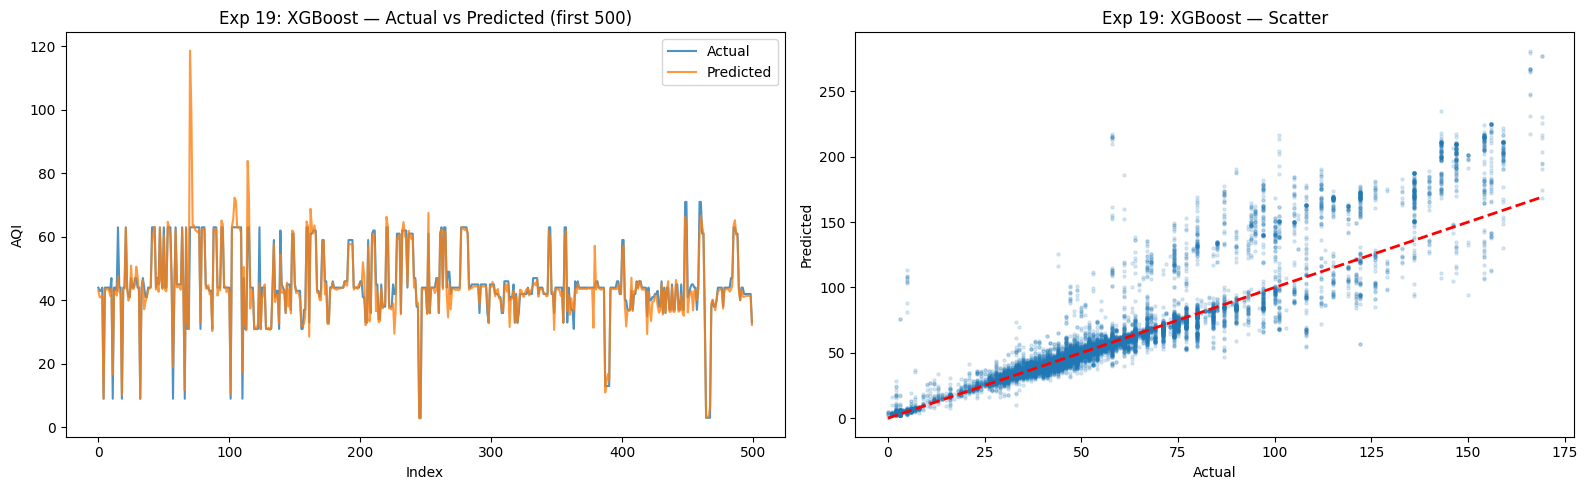

In [ ]:
# Train final XGBoost with best params
xgb_model = xgb.XGBRegressor(
    **study_xgb.best_params,
    tree_method='hist', random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_pred_xgb = xgb_model.predict(X_test)
res = evaluate(y_test, y_pred_xgb, "Exp19-XGBoost")
results.append(res)
plot_predictions(y_test, y_pred_xgb, "Exp 19: XGBoost")


---
## Experiment 20: LightGBM with Optuna Tuning
LightGBM uses histogram-based learning and leaf-wise growth, making it faster and often more accurate than XGBoost on large datasets.

In [ ]:
def lgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1500),
        'max_depth':         trial.suggest_int('max_depth', -1, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 256),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
    }
    model = lgb.LGBMRegressor(**params, random_state=42, verbosity=-1)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    pred = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, pred))

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(lgb_objective, n_trials=50, show_progress_bar=True)
print(f"Best LightGBM RMSE (val): {study_lgb.best_value:.3f}")


  0%|          | 0/50 [00:00<?, ?it/s]

Best LightGBM RMSE (val): 12.304


[Exp20-LightGBM]  MSE: 75.531 | RMSE: 8.691 | MAE: 4.195 | R²: 0.9047


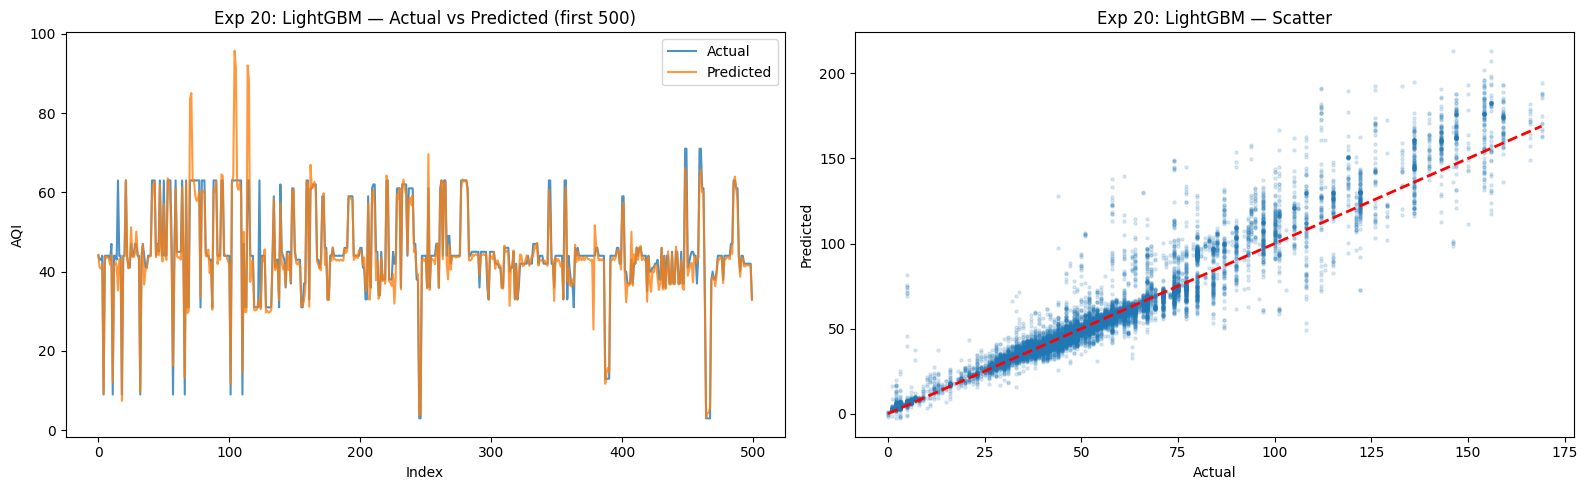

In [ ]:
lgb_model = lgb.LGBMRegressor(
    **study_lgb.best_params, random_state=42, verbosity=-1
)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

y_pred_lgb = lgb_model.predict(X_test)
res = evaluate(y_test, y_pred_lgb, "Exp20-LightGBM")
results.append(res)
plot_predictions(y_test, y_pred_lgb, "Exp 20: LightGBM")


---
## Experiment 21: CatBoost with Optuna Tuning
CatBoost uses ordered boosting and symmetric trees, making it robust to overfitting with minimal tuning.

In [ ]:
def cat_objective(trial):
    params = {
        'iterations':        trial.suggest_int('iterations', 300, 1500),
        'depth':             trial.suggest_int('depth', 4, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':       trial.suggest_float('l2_leaf_reg', 1e-2, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':   trial.suggest_float('random_strength', 1e-2, 10, log=True),
    }
    model = CatBoostRegressor(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=0)
    pred = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, pred))

study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(cat_objective, n_trials=40, show_progress_bar=True)
print(f"Best CatBoost RMSE (val): {study_cat.best_value:.3f}")


  0%|          | 0/40 [00:00<?, ?it/s]

Best CatBoost RMSE (val): 8.438


[Exp21-CatBoost]  MSE: 73.581 | RMSE: 8.578 | MAE: 4.496 | R²: 0.9071


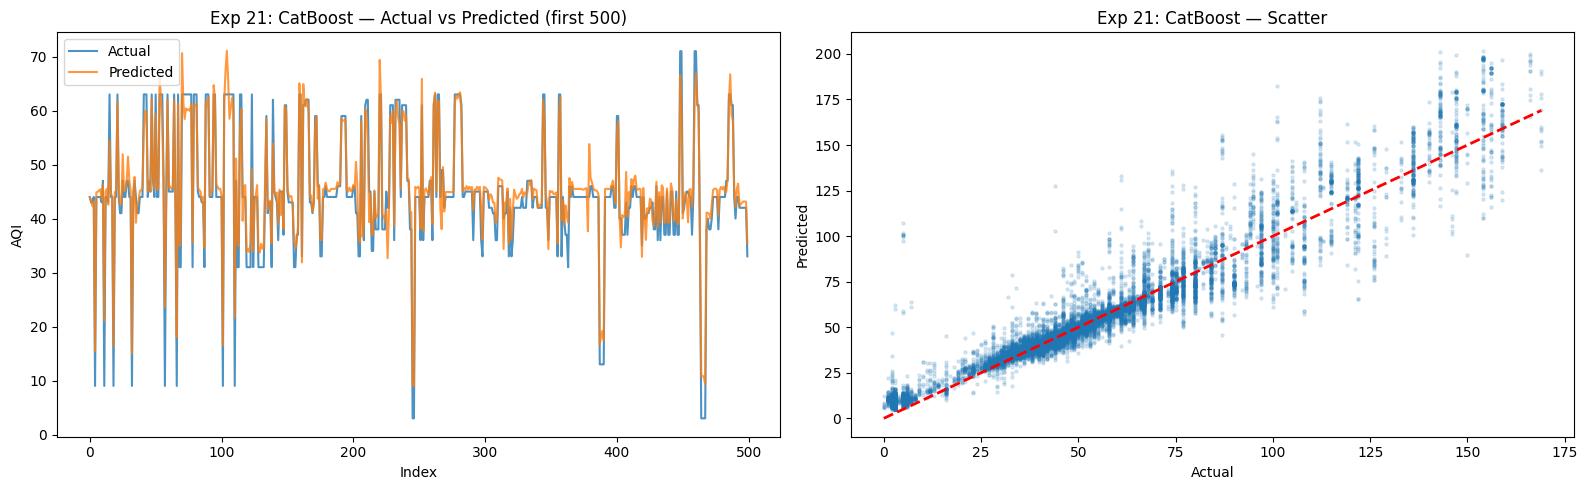

In [ ]:
cat_model = CatBoostRegressor(
    **study_cat.best_params, random_state=42, verbose=0
)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=0)

y_pred_cat = cat_model.predict(X_test)
res = evaluate(y_test, y_pred_cat, "Exp21-CatBoost")
results.append(res)
plot_predictions(y_test, y_pred_cat, "Exp 21: CatBoost")


---
## Experiment 22: Stacking Ensemble
Combines Ridge, XGBoost, LightGBM, and CatBoost predictions using a Ridge meta-learner. This leverages each model's strengths for a more robust prediction.

Training Stacking Ensemble (this may take a few minutes)...
[Exp22-StackingEnsemble]  MSE: 35.682 | RMSE: 5.973 | MAE: 3.276 | R²: 0.9550


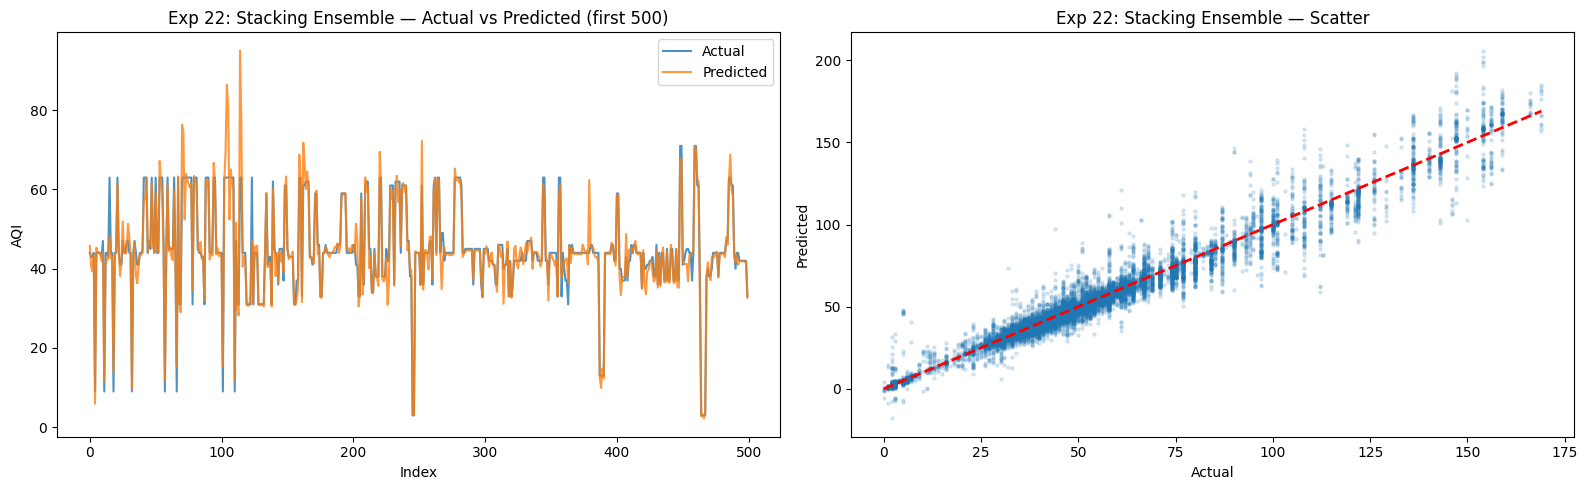

In [ ]:
from sklearn.base import clone

# Build a stacking ensemble using the best tuned models
stack_model = StackingRegressor(
    estimators=[
        ('ridge', Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])),
        ('xgb',   xgb.XGBRegressor(**study_xgb.best_params, tree_method='hist',
                                     random_state=42, verbosity=0)),
        ('lgb',   lgb.LGBMRegressor(**study_lgb.best_params, random_state=42, verbosity=-1)),
        ('cat',   CatBoostRegressor(**study_cat.best_params, random_state=42, verbose=0)),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

# Combine train + val for stacking CV (it uses internal cross-validation)
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

print("Training Stacking Ensemble (this may take a few minutes)...")
stack_model.fit(X_trainval, y_trainval)

y_pred_stack = stack_model.predict(X_test)
res = evaluate(y_test, y_pred_stack, "Exp22-StackingEnsemble")
results.append(res)
plot_predictions(y_test, y_pred_stack, "Exp 22: Stacking Ensemble")


---
## Experiment 23: Temporal Convolutional Network (TCN)
TCN uses dilated causal convolutions to capture temporal patterns with a large receptive field while maintaining computational efficiency. Unlike LSTMs, TCNs can process sequences in parallel.

In [ ]:
# ---- Build sequences for deep learning models ----
TIME_STEPS = 14  # 14-day lookback window

scaler_feat = MinMaxScaler().fit(X_train)
scaler_y = RobustScaler().fit(y_train.reshape(-1,1))

def prepare_dl_data(df_part, scaler_feat, scaler_y):
    X_s = scaler_feat.transform(df_part[FEATURES].values)
    y_s = scaler_y.transform(df_part[TARGET].values.reshape(-1,1)).flatten()
    return X_s, y_s

X_tr_s, y_tr_s = prepare_dl_data(train_df, scaler_feat, scaler_y)
X_va_s, y_va_s = prepare_dl_data(val_df, scaler_feat, scaler_y)
X_te_s, y_te_s = prepare_dl_data(test_df, scaler_feat, scaler_y)

def build_sequences(X, y, group_keys, time_steps):
    """Build sequences grouped by station to avoid cross-station leakage."""
    Xs, ys = [], []
    unique_groups = group_keys.drop_duplicates().values
    for gk in unique_groups:
        mask = (group_keys == gk).all(axis=1).values if len(gk.shape) > 0 else (group_keys == gk).values
        idx = np.where(mask)[0]
        if len(idx) <= time_steps:
            continue
        Xg, yg = X[idx], y[idx]
        for i in range(len(Xg) - time_steps):
            Xs.append(Xg[i:i+time_steps])
            ys.append(yg[i+time_steps])
    return np.array(Xs), np.array(ys)

# Build grouped sequences
tr_groups = train_df[GROUP_COLS].reset_index(drop=True)
va_groups = val_df[GROUP_COLS].reset_index(drop=True)
te_groups = test_df[GROUP_COLS].reset_index(drop=True)

# Use a simpler, faster approach: create a group key string
tr_gk = train_df[GROUP_COLS].astype(str).agg('-'.join, axis=1).reset_index(drop=True)
va_gk = val_df[GROUP_COLS].astype(str).agg('-'.join, axis=1).reset_index(drop=True)
te_gk = test_df[GROUP_COLS].astype(str).agg('-'.join, axis=1).reset_index(drop=True)

def build_seqs_fast(X, y, gk, time_steps):
    Xs, ys = [], []
    for key in gk.unique():
        idx = gk[gk == key].index.values
        if len(idx) <= time_steps:
            continue
        Xg, yg = X[idx], y[idx]
        for i in range(len(Xg) - time_steps):
            Xs.append(Xg[i:i+time_steps])
            ys.append(yg[i+time_steps])
    return np.array(Xs), np.array(ys)

X_seq_tr, y_seq_tr = build_seqs_fast(X_tr_s, y_tr_s, tr_gk, TIME_STEPS)
X_seq_va, y_seq_va = build_seqs_fast(X_va_s, y_va_s, va_gk, TIME_STEPS)
X_seq_te, y_seq_te = build_seqs_fast(X_te_s, y_te_s, te_gk, TIME_STEPS)

print(f"Sequence shapes -> Train: {X_seq_tr.shape}, Val: {X_seq_va.shape}, Test: {X_seq_te.shape}")


Sequence shapes -> Train: (59618, 14, 27), Val: (5480, 14, 27), Test: (15895, 14, 27)


In [ ]:
# ---- TCN Model ----
def build_tcn(input_shape, num_filters=64, kernel_size=3, dilations=[1,2,4,8]):
    inp = Input(shape=input_shape)
    x = inp
    for d in dilations:
        # Causal dilated convolution block
        conv = Conv1D(filters=num_filters, kernel_size=kernel_size,
                      dilation_rate=d, padding='causal', activation='relu')(x)
        conv = Dropout(0.2)(conv)
        conv = Conv1D(filters=num_filters, kernel_size=kernel_size,
                      dilation_rate=d, padding='causal', activation='relu')(conv)
        conv = Dropout(0.2)(conv)
        # Residual connection
        if x.shape[-1] != num_filters:
            x = Conv1D(num_filters, 1, padding='same')(x)
        x = Add()([x, conv])
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(1)(x)
    model = Model(inp, out)
    return model

tcn_model = build_tcn(
    input_shape=(TIME_STEPS, len(FEATURES)),
    num_filters=64,
    kernel_size=3,
    dilations=[1, 2, 4, 8]
)

tcn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=['mae']
)
tcn_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 14, 27)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 14, 64)    │      5,248 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 14, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 14, 64)    │      1,792 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 14, 64)    │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 14, 64)    │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 14, 64)    │     12,352 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 14, 64)    │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 14, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 14, 64)    │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 14, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 14, 64)    │     12,352 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 14, 64)    │          0 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 14, 64)    │     12,352 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 14, 64)    │          0 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 14, 64)    │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 14, 64)    │     12,352 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 14, 64)    │          0 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 14, 64)    │     12,352 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 14, 64)    │          0 │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 14, 64)    │          0 │ add_2[0][0],      │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 97,729 (381.75 KB)

 Trainable params: 97,729 (381.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.2655 - mae: 0.5504 - val_loss: 0.0941 - val_mae: 0.3044 - learning_rate: 0.0010
Epoch 2/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1815 - mae: 0.4209 - val_loss: 0.0750 - val_mae: 0.2612 - learning_rate: 0.0010
Epoch 3/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1571 - mae: 0.3786 - val_loss: 0.0699 - val_mae: 0.2635 - learning_rate: 0.0010
Epoch 4/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1451 - mae: 0.3560 - val_loss: 0.0812 - val_mae: 0.3068 - learning_rate: 0.0010
Epoch 5/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1352 - mae: 0.3390 - val_loss: 0.0732 - val_mae: 0.2566 - learning_rate: 0.0010
Epoch 6/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1310 - mae: 0.3302 - val_loss: 0.0599 - val_mae: 0.2270 - learning_rate: 0.0010
Epoch 7/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1279 - mae: 0.3245 - val_loss: 0.0549 - val_mae: 0.2142 - learning_rate: 0.00

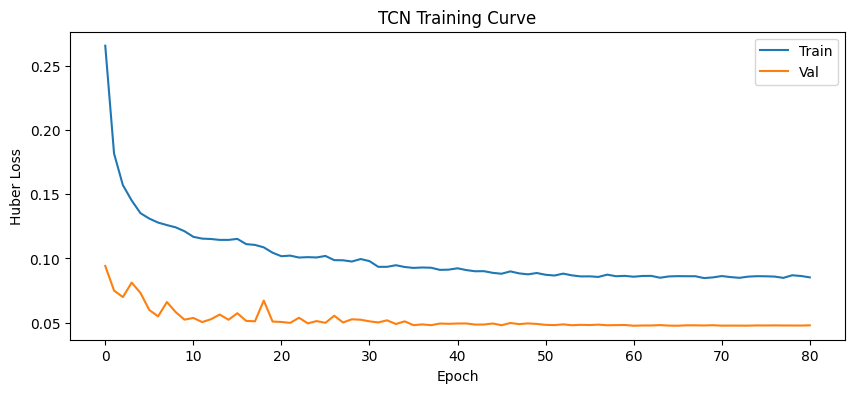

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

history_tcn = tcn_model.fit(
    X_seq_tr, y_seq_tr,
    validation_data=(X_seq_va, y_seq_va),
    epochs=150, batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training curves
plt.figure(figsize=(10,4))
plt.plot(history_tcn.history['loss'], label='Train')
plt.plot(history_tcn.history['val_loss'], label='Val')
plt.title('TCN Training Curve'); plt.xlabel('Epoch'); plt.ylabel('Huber Loss'); plt.legend(); plt.show()


497/497 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
[Exp23-TCN]  MSE: 241.925 | RMSE: 15.554 | MAE: 9.132 | R²: 0.7196


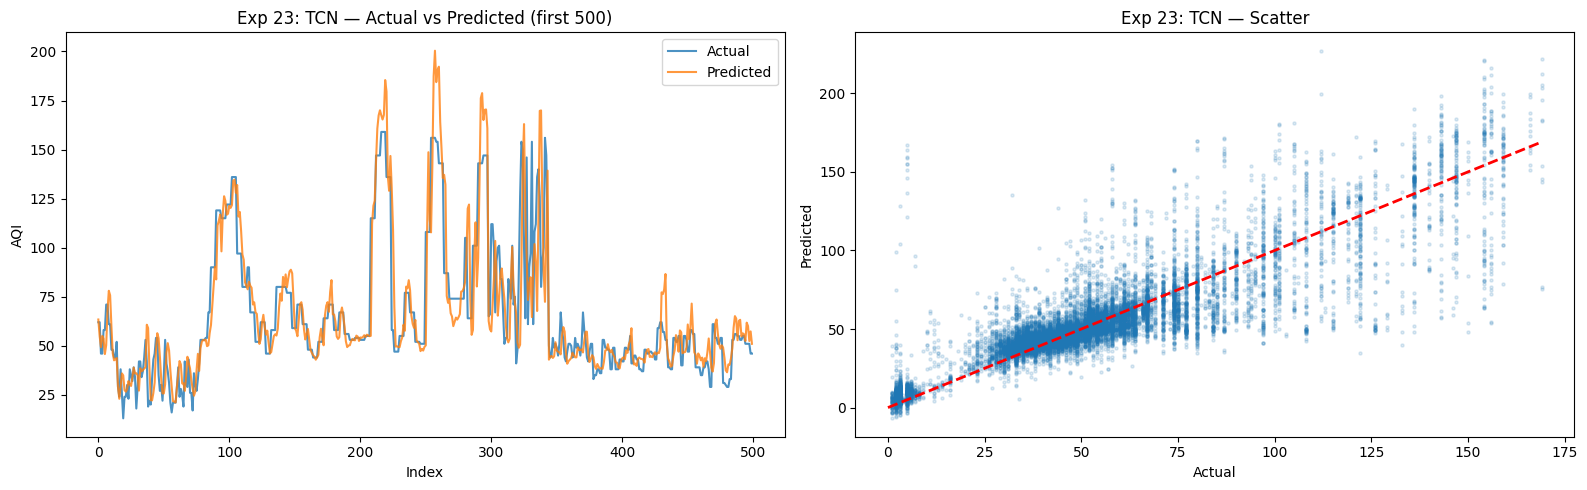

In [ ]:
# Evaluate TCN
y_pred_tcn_s = tcn_model.predict(X_seq_te).flatten()
y_pred_tcn = scaler_y.inverse_transform(y_pred_tcn_s.reshape(-1,1)).flatten()
y_true_tcn = scaler_y.inverse_transform(y_seq_te.reshape(-1,1)).flatten()

res = evaluate(y_true_tcn, y_pred_tcn, "Exp23-TCN")
results.append(res)
plot_predictions(y_true_tcn, y_pred_tcn, "Exp 23: TCN")


---
## Experiment 24: Transformer Encoder for Time Series


In [ ]:
def build_transformer(input_shape, head_size=64, num_heads=4, ff_dim=128,
                      num_blocks=3, dropout=0.2):
    inp = Input(shape=input_shape)
    x = Dense(head_size * num_heads)(inp)  # Project to model dimension

    for _ in range(num_blocks):
        # Multi-head self-attention
        attn = LayerNormalization(epsilon=1e-6)(x)
        attn = MultiHeadAttention(
            num_heads=num_heads, key_dim=head_size, dropout=dropout
        )(attn, attn)
        attn = Dropout(dropout)(attn)
        x = Add()([x, attn])

        # Feed-forward network
        ff = LayerNormalization(epsilon=1e-6)(x)
        ff = Dense(ff_dim, activation='relu')(ff)
        ff = Dropout(dropout)(ff)
        ff = Dense(head_size * num_heads)(ff)
        ff = Dropout(dropout)(ff)
        x = Add()([x, ff])

    x = LayerNormalization(epsilon=1e-6)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)
    out = Dense(1)(x)
    return Model(inp, out)

transformer_model = build_transformer(
    input_shape=(TIME_STEPS, len(FEATURES)),
    head_size=32, num_heads=4, ff_dim=128,
    num_blocks=3, dropout=0.2
)

transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=['mae']
)
transformer_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 14, 27)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 14, 128)   │      3,584 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 14, 128)   │        256 │ dense_2[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 14, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 14, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 14, 128)   │          0 │ dense_2[0][0],    │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 128)   │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 14, 128)   │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 14, 128)   │          0 │ dense_3[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 14, 128)   │     16,512 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 14, 128)   │          0 │ dense_4[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 14, 128)   │          0 │ add_4[0][0],      │
│                     │                   │            │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 128)   │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 14, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 14, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 14, 128)   │          0 │ add_5[0][0],      │
│                     │                   │            │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 128)   │        256 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 14, 128)   │     16,512 │ layer_normalizat

 Total params: 310,913 (1.19 MB)

 Trainable params: 310,913 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - loss: 0.2883 - mae: 0.5798 - val_loss: 0.1100 - val_mae: 0.3538 - learning_rate: 0.0010
Epoch 2/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1937 - mae: 0.4401 - val_loss: 0.1024 - val_mae: 0.3344 - learning_rate: 0.0010
Epoch 3/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1759 - mae: 0.4081 - val_loss: 0.1136 - val_mae: 0.3415 - learning_rate: 0.0010
Epoch 4/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1670 - mae: 0.3918 - val_loss: 0.1053 - val_mae: 0.3225 - learning_rate: 0.0010
Epoch 5/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1573 - mae: 0.3746 - val_loss: 0.0957 - val_mae: 0.3248 - learning_rate: 0.0010
Epoch 6/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1569 - mae: 0.3708 - val_loss: 0.0883 - val_mae: 0.3111 - learning_rate: 0.0010
Epoch 7/150
466/466 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1486 - mae: 0.3584 - val_loss: 0.0707 - val_mae: 0.2362 - learning_rate: 0.00

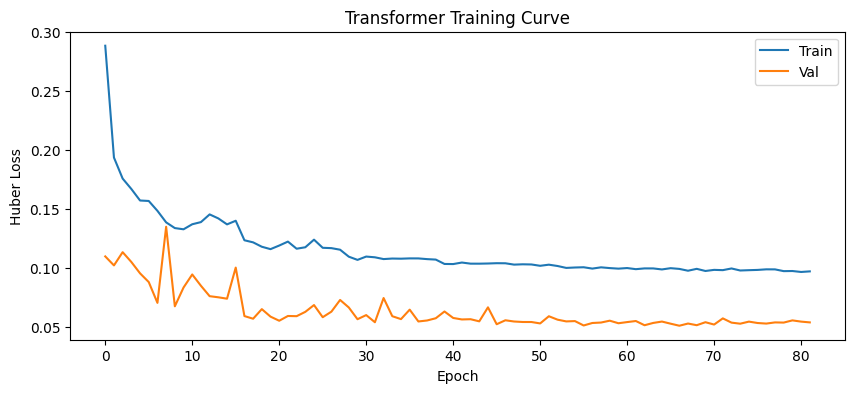

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

history_tf = transformer_model.fit(
    X_seq_tr, y_seq_tr,
    validation_data=(X_seq_va, y_seq_va),
    epochs=150, batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plt.figure(figsize=(10,4))
plt.plot(history_tf.history['loss'], label='Train')
plt.plot(history_tf.history['val_loss'], label='Val')
plt.title('Transformer Training Curve'); plt.xlabel('Epoch'); plt.ylabel('Huber Loss'); plt.legend(); plt.show()


497/497 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
[Exp24-Transformer]  MSE: 299.011 | RMSE: 17.292 | MAE: 11.261 | R²: 0.6534


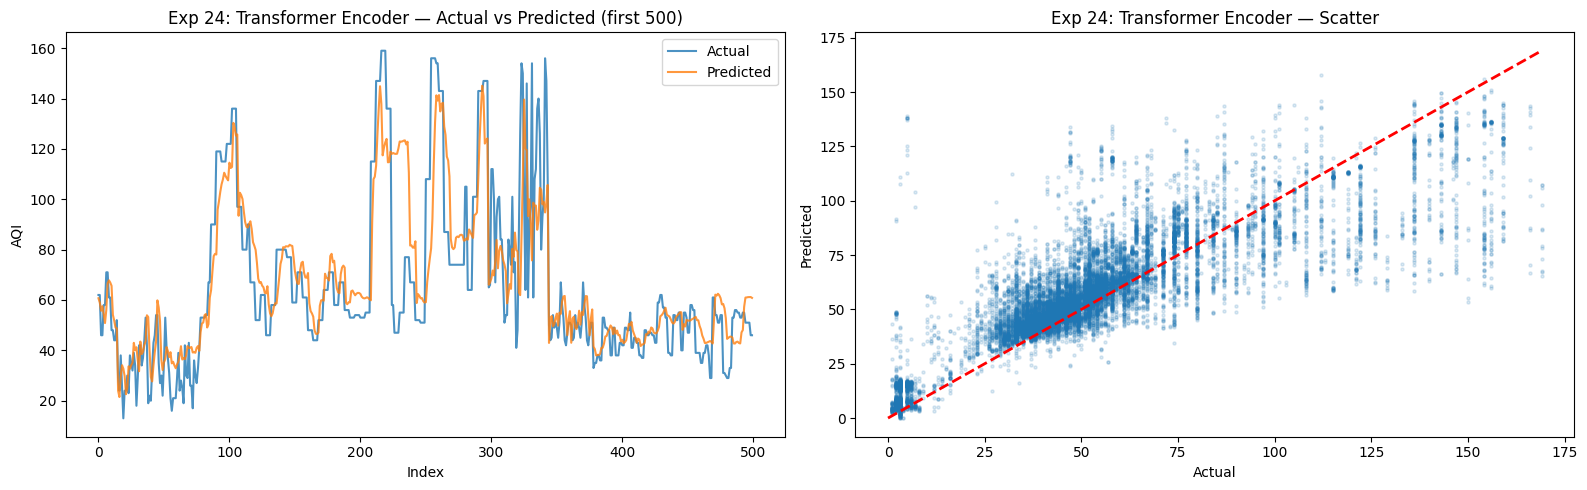

In [ ]:
y_pred_tf_s = transformer_model.predict(X_seq_te).flatten()
y_pred_tf = scaler_y.inverse_transform(y_pred_tf_s.reshape(-1,1)).flatten()
y_true_tf = scaler_y.inverse_transform(y_seq_te.reshape(-1,1)).flatten()

res = evaluate(y_true_tf, y_pred_tf, "Exp24-Transformer")
results.append(res)
plot_predictions(y_true_tf, y_pred_tf, "Exp 24: Transformer Encoder")


---
## 7. Explainability Analysis (SHAP + LIME + Permutation Importance)


Computing SHAP values for XGBoost...


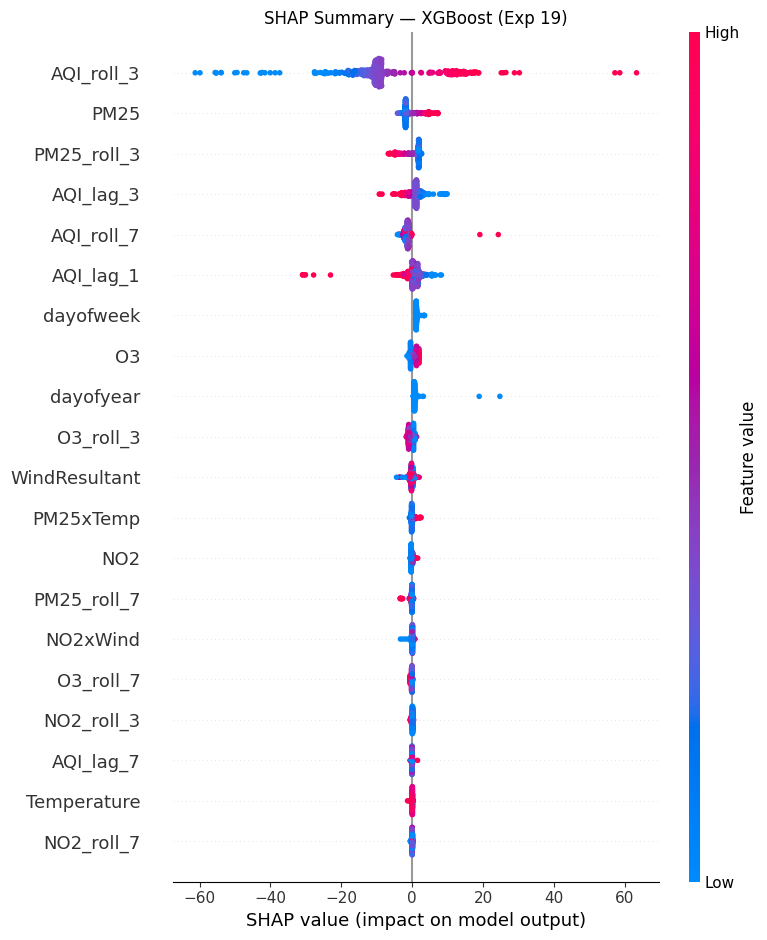

In [ ]:
# ---- SHAP for best tree model (XGBoost) ----
print("Computing SHAP values for XGBoost...")
explainer_shap = shap.TreeExplainer(xgb_model)
shap_values = explainer_shap.shap_values(X_test[:500])

plt.figure()
shap.summary_plot(shap_values, X_test[:500], feature_names=FEATURES, show=False)
plt.title("SHAP Summary — XGBoost (Exp 19)")
plt.tight_layout(); plt.show()


Computing SHAP values for LightGBM...


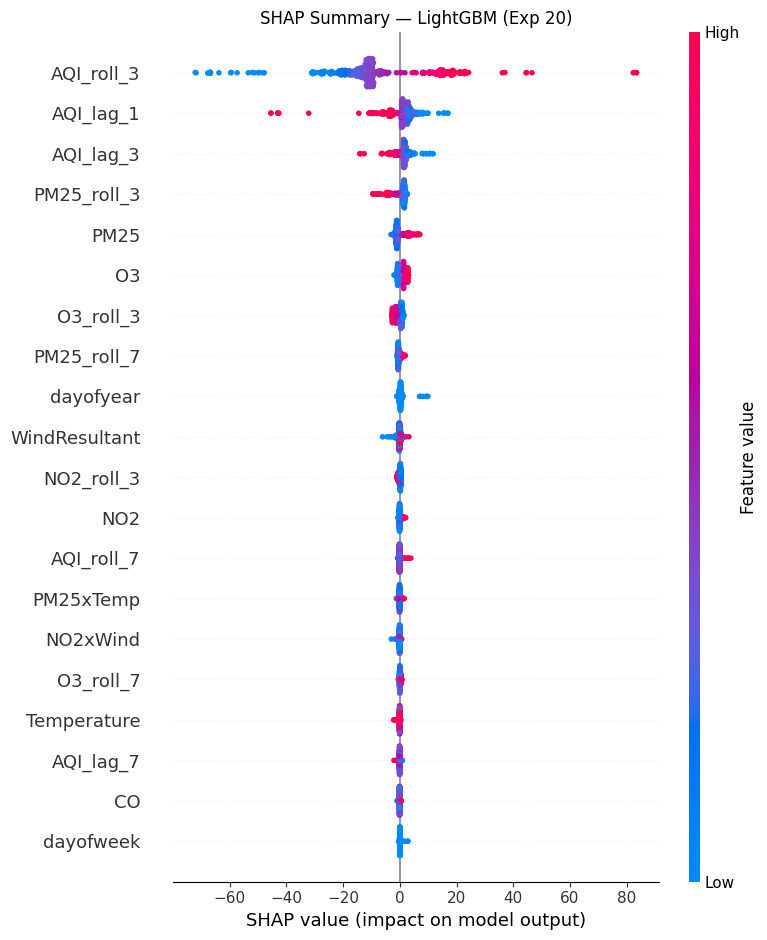

In [ ]:
# ---- SHAP for LightGBM ----
print("Computing SHAP values for LightGBM...")
explainer_lgb = shap.TreeExplainer(lgb_model)
shap_values_lgb = explainer_lgb.shap_values(X_test[:500])

plt.figure()
shap.summary_plot(shap_values_lgb, X_test[:500], feature_names=FEATURES, show=False)
plt.title("SHAP Summary — LightGBM (Exp 20)")
plt.tight_layout(); plt.show()


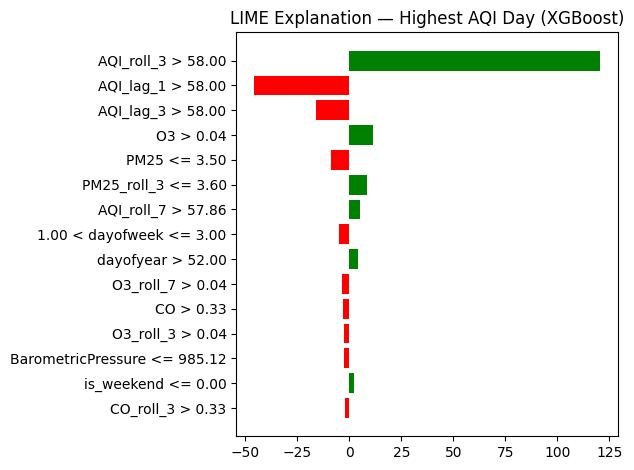

In [ ]:
# ---- LIME Explanation (single instance) ----
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=FEATURES,
    mode='regression'
)

# Explain a high-AQI test instance for interpretability
high_aqi_idx = np.argmax(y_test)
exp = lime_explainer.explain_instance(
    data_row=X_test[high_aqi_idx],
    predict_fn=xgb_model.predict,
    num_features=15
)
exp.as_pyplot_figure()
plt.title("LIME Explanation — Highest AQI Day (XGBoost)")
plt.tight_layout(); plt.show()


Computing permutation importance for Stacking Ensemble...


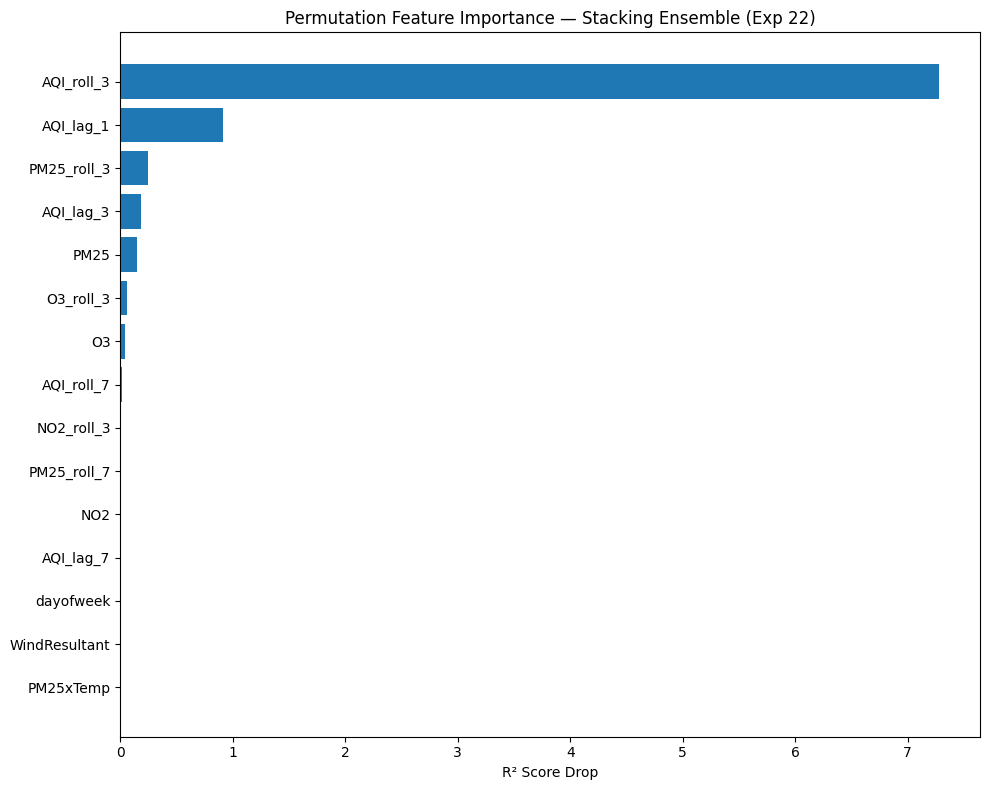

          Feature  Importance
11     AQI_roll_3    7.280040
8       AQI_lag_1    0.911894
17    PM25_roll_3    0.242126
9       AQI_lag_3    0.182146
4            PM25    0.144154
19      O3_roll_3    0.062495
3              O3    0.043213
12     AQI_roll_7    0.013502
15     NO2_roll_3    0.003241
18    PM25_roll_7    0.002012
2             NO2    0.001981
10      AQI_lag_7    0.001521
22      dayofweek    0.001052
7   WindResultant    0.001027
25      PM25xTemp    0.001016


In [ ]:
# ---- Permutation Feature Importance for Stacking Ensemble ----
from sklearn.inspection import permutation_importance

print("Computing permutation importance for Stacking Ensemble...")
perm_result = permutation_importance(
    stack_model, X_test, y_test, n_repeats=5, random_state=42, scoring='r2'
)

perm_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': perm_result.importances_mean
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,8))
plt.barh(perm_df['Feature'][:15], perm_df['Importance'][:15])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance — Stacking Ensemble (Exp 22)")
plt.xlabel("R² Score Drop"); plt.tight_layout(); plt.show()
print(perm_df.head(15))


---
## 8. Final Results Comparison
Combining new experiments with the original paper's results for a complete benchmark.

In [ ]:
# Original paper results for comparison
original_results = [
    {'Model': 'Exp1-LR (raw)',              'MSE': 733.080, 'RMSE': 27.075, 'MAE': 13.094, 'R2': None},
    {'Model': 'Exp3-RF (raw)',              'MSE': 137.300, 'RMSE': 11.717, 'MAE': 3.389,  'R2': None},
    {'Model': 'Exp5-RF+Optuna (raw)',       'MSE': 132.927, 'RMSE': 11.529, 'MAE': 2.974,  'R2': None},
    {'Model': 'Exp6-LSTM (raw)',            'MSE': 3437.243,'RMSE': 58.628, 'MAE': 22.403, 'R2': None},
    {'Model': 'Exp8-LSTM (eng)',            'MSE': 279.115, 'RMSE': 16.707, 'MAE': 9.890,  'R2': None},
    {'Model': 'Exp9-LR (eng)',              'MSE': 34.560,  'RMSE': 5.879,  'MAE': 3.309,  'R2': None},
    {'Model': 'Exp10-RF (eng)',             'MSE': 58.986,  'RMSE': 7.680,  'MAE': 3.477,  'R2': None},
    {'Model': 'Exp11-BiLSTM (eng)',         'MSE': 3560.198,'RMSE': 59.667, 'MAE': 23.682, 'R2': None},
    {'Model': 'Exp12-CNN-LSTM (eng)',       'MSE': 3090.551,'RMSE': 55.593, 'MAE': 20.708, 'R2': None},
    {'Model': 'Exp16-BiLSTM+tune (eng)',    'MSE': 766.995, 'RMSE': 27.695, 'MAE': 17.967, 'R2': None},
    {'Model': 'Exp17-CNN-LSTM+tune (eng)',  'MSE': 822.826, 'RMSE': 28.685, 'MAE': 18.304, 'R2': None},
    {'Model': 'Exp18-GNN (eng)',            'MSE': 2319.422,'RMSE': 48.160, 'MAE': 42.482, 'R2': None},
]

all_results = original_results + results
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('RMSE').reset_index(drop=True)

print("=" * 80)
print("COMPLETE PERFORMANCE COMPARISON (sorted by RMSE)")
print("=" * 80)
print(results_df.to_string(index=False))


COMPLETE PERFORMANCE COMPARISON (sorted by RMSE)
                    Model      MSE   RMSE    MAE     R2
            Exp9-LR (eng)   34.560  5.879  3.309    NaN
   Exp22-StackingEnsemble   35.682  5.973  3.276 0.9550
           Exp10-RF (eng)   58.986  7.680  3.477    NaN
           Exp21-CatBoost   73.581  8.578  4.496 0.9071
           Exp20-LightGBM   75.531  8.691  4.195 0.9047
     Exp5-RF+Optuna (raw)  132.927 11.529  2.974    NaN
            Exp3-RF (raw)  137.300 11.717  3.389    NaN
            Exp19-XGBoost  236.991 15.395  6.291 0.7009
                Exp23-TCN  241.925 15.554  9.132 0.7196
          Exp8-LSTM (eng)  279.115 16.707  9.890    NaN
        Exp24-Transformer  299.011 17.292 11.261 0.6534
            Exp1-LR (raw)  733.080 27.075 13.094    NaN
  Exp16-BiLSTM+tune (eng)  766.995 27.695 17.967    NaN
Exp17-CNN-LSTM+tune (eng)  822.826 28.685 18.304    NaN
          Exp18-GNN (eng) 2319.422 48.160 42.482    NaN
     Exp12-CNN-LSTM (eng) 3090.551 55.593 20.708    NaN

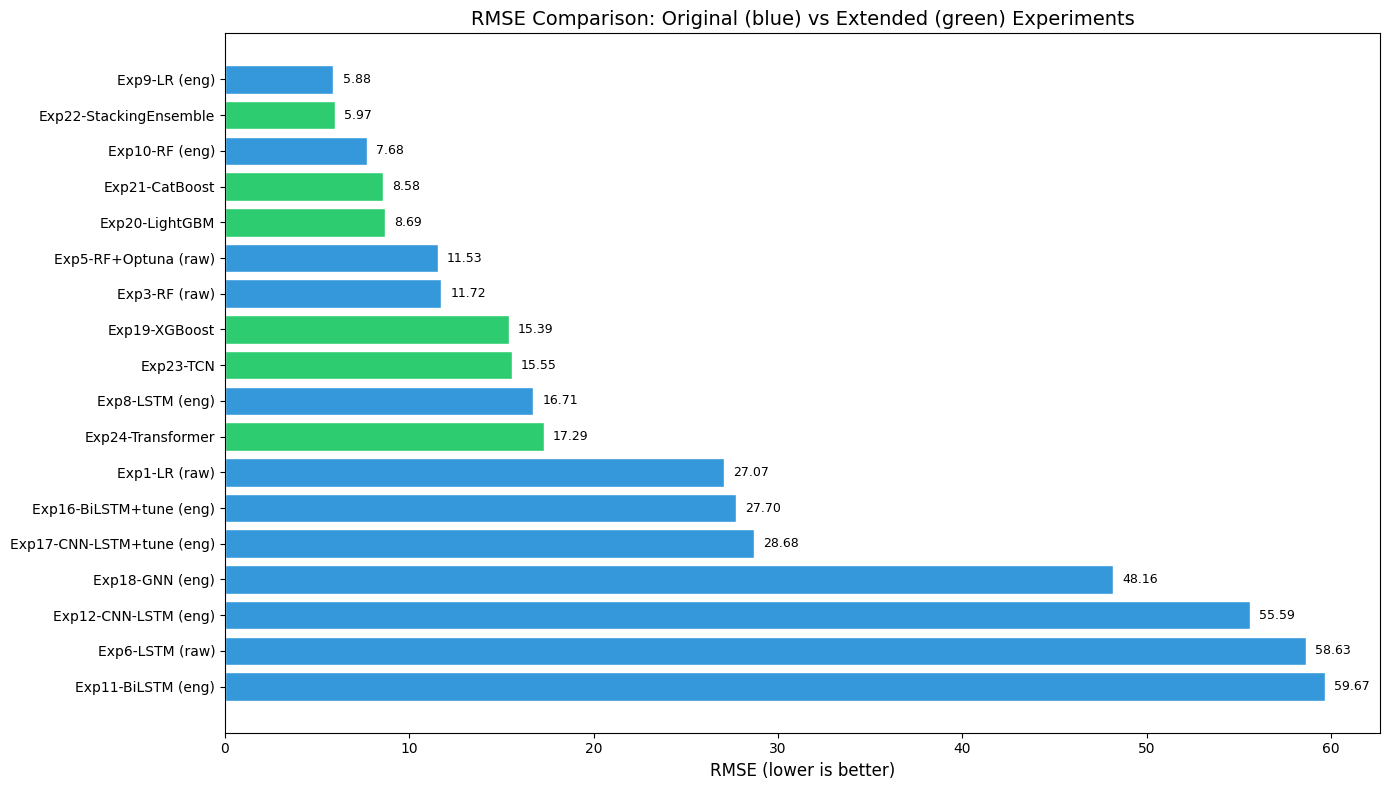

In [ ]:
# ---- Visualization: RMSE comparison bar chart ----
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#2ecc71' if 'Exp19' in m or 'Exp20' in m or 'Exp21' in m or
          'Exp22' in m or 'Exp23' in m or 'Exp24' in m
          else '#3498db' for m in results_df['Model']]

bars = ax.barh(results_df['Model'], results_df['RMSE'], color=colors, edgecolor='white')
ax.set_xlabel('RMSE (lower is better)', fontsize=12)
ax.set_title('RMSE Comparison: Original (blue) vs Extended (green) Experiments', fontsize=14)
ax.invert_yaxis()

for bar, val in zip(bars, results_df['RMSE']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout(); plt.show()


In [ ]:
# ---- New experiments only: detailed comparison ----
new_df = pd.DataFrame(results).sort_values('RMSE')
print("\n" + "=" * 70)
print("NEW EXPERIMENTS — DETAILED RESULTS")
print("=" * 70)
print(new_df.to_string(index=False))

best = new_df.iloc[0]
print(f"\nBest new model: {best['Model']} with RMSE = {best['RMSE']}")
print(f"Compared to original best (LR eng, RMSE=5.879):")
improvement = ((5.879 - best['RMSE']) / 5.879) * 100
if improvement > 0:
    print(f"  → {improvement:.1f}% improvement!")
else:
    print(f"  → Competitive result (within {abs(improvement):.1f}%)")



NEW EXPERIMENTS — DETAILED RESULTS
                 Model     MSE   RMSE    MAE     R2
Exp22-StackingEnsemble  35.682  5.973  3.276 0.9550
        Exp21-CatBoost  73.581  8.578  4.496 0.9071
        Exp20-LightGBM  75.531  8.691  4.195 0.9047
         Exp19-XGBoost 236.991 15.395  6.291 0.7009
             Exp23-TCN 241.925 15.554  9.132 0.7196
     Exp24-Transformer 299.011 17.292 11.261 0.6534

Best new model: Exp22-StackingEnsemble with RMSE = 5.973
Compared to original best (LR eng, RMSE=5.879):
  → Competitive result (within 1.6%)
